In [1]:
import nifty.re as jft
import jax.numpy as jnp
import jax
import jax.random as random
import matplotlib.pyplot as plt
import healpy as hp

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [2]:
seed = 67
key = random.PRNGKey(seed)
shape = (128, 128)
shape_sp = 256

distances = 1

jax.config.update("jax_enable_x64", True)

In [3]:
cfm_args = {
    "offset_mean": 25.0,
    "offset_std": (3.0, 1.0),
    "fluctuations": (2.0, 1.0),
    "asperity": None,
    "loglogavgslope": (-2.0, 0.3),
    "flexibility": None,
    "prefix": 'temp'
}
cfm = jft.CorrelatedFieldMaker(cfm_args['prefix']) 

cfm.set_amplitude_total_offset(cfm_args["offset_mean"], cfm_args["offset_std"])

cfm_args.pop('offset_mean')
cfm_args.pop('offset_std')
cfm.add_fluctuations(shape, distances, **cfm_args)
# cfm.add_fluctuations(shape_sp, distances, **cfm_args, harmonic_type='spherical')


cf_model = cfm.finalize()


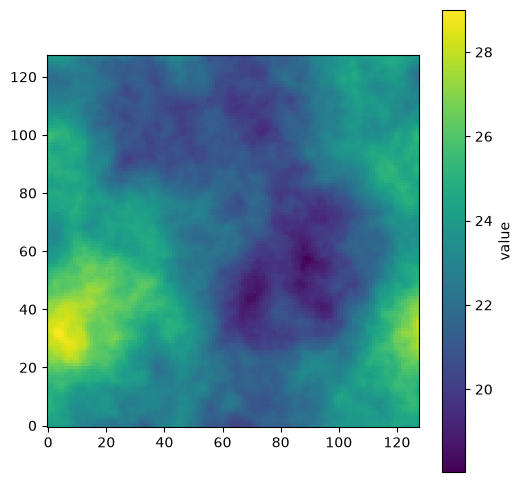

In [4]:
inp = jft.random_like(key, cf_model.domain)

# print(cf_model.target)

field = cf_model(inp)

# hp.mollview(field, norm = 'hist')

# jnp.mean(field)
# jnp.std(field)

plt.figure(figsize=(6, 6))
plt.imshow(field, origin="lower", cmap="viridis", interpolation="nearest")
plt.colorbar(label="value")
